# 05 Insights and recommendations

This notebook converts the rent-inclusive candidate comparison
into a close three-parish shortlist and a documented
due-diligence plan. It is a market-screening recommendation,
not approval to sign a lease.

## 1. Imports and validated shortlist

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FIGURES_DIR,
    FINAL_WEIGHTS,
    RANDOM_STATE,
    SENSITIVITY_ITERATIONS,
    TABLES_DIR,
)
from src.utils import save_figure, validate_required_columns

sns.set_theme(style="whitegrid", context="notebook")
shortlist_path = TABLES_DIR / "rent_inclusive_pilot_ranking.csv"
shortlist = pd.read_csv(shortlist_path)

required_columns = {
    "parish",
    "demand_proxy_score",
    "transit_access_score",
    "competition_opportunity_score",
    "rent_opportunity_score",
    "median_rent_eur_m2_month",
    "rent_sample_size",
    "pilot_opportunity_score",
    "pilot_rank",
}
validate_required_columns(shortlist, required_columns)
assert len(shortlist) == 10
assert shortlist["rent_sample_size"].ge(5).all()
shortlist.head()

,parish,demand_proxy_score,transit_access_score,competition_opportunity_score,median_rent_eur_m2_month,rent_sample_size,rent_opportunity_score,pilot_opportunity_score,pilot_rank
0,Lumiar,43.33,67.50,95.65,15.71,17,88.89,69.29,1
1,Arroios,94.17,95.00,13.04,17.50,15,61.11,69.14,2
2,Areeiro,85.42,73.33,52.17,17.73,10,44.44,67.94,3
3,São Domingos de Benfica,67.08,65.00,56.52,16.99,14,77.78,65.52,4
4,Avenidas Novas,84.58,90.83,21.74,20.38,22,22.22,61.08,5


## 2. Four-component weight sensitivity

Five thousand plausible weight combinations are sampled around
the planned 35/25/25/15 weights. This checks whether the
recommendation depends on one exact subjective weighting.

In [2]:
component_columns = list(FINAL_WEIGHTS)
base_weights = np.array(
    [FINAL_WEIGHTS[column] for column in component_columns]
)
rng = np.random.default_rng(RANDOM_STATE)
sampled_weights = rng.dirichlet(
    base_weights * 40,
    size=SENSITIVITY_ITERATIONS,
)
score_matrix = (
    shortlist[component_columns].to_numpy() @ sampled_weights.T
)
order = np.argsort(-score_matrix, axis=0)
simulation_ranks = np.empty_like(order)
simulation_ranks[order, np.arange(SENSITIVITY_ITERATIONS)] = (
    np.arange(1, len(shortlist) + 1)[:, None]
)

sensitivity = pd.DataFrame(
    {
        "parish": shortlist["parish"],
        "top1_share": (simulation_ranks == 1).mean(axis=1) * 100,
        "top3_share": (simulation_ranks <= 3).mean(axis=1) * 100,
        "median_rank": np.median(simulation_ranks, axis=1),
        "best_rank": simulation_ranks.min(axis=1),
        "worst_rank": simulation_ranks.max(axis=1),
    }
)
sensitivity[["top1_share", "top3_share"]] = sensitivity[
    ["top1_share", "top3_share"]
].round(2)
decision_table = shortlist.merge(
    sensitivity,
    on="parish",
    how="left",
    validate="one_to_one",
).sort_values(["pilot_rank", "parish"])
decision_table.head()

,parish,demand_proxy_score,transit_access_score,competition_opportunity_score,median_rent_eur_m2_month,rent_sample_size,rent_opportunity_score,pilot_opportunity_score,pilot_rank,top1_share,top3_share,median_rank,best_rank,worst_rank
0,Lumiar,43.33,67.50,95.65,15.71,17,88.89,69.29,1,48.24,79.30,2.0,1,8
1,Arroios,94.17,95.00,13.04,17.50,15,61.11,69.14,2,46.48,77.36,2.0,1,6
2,Areeiro,85.42,73.33,52.17,17.73,10,44.44,67.94,3,5.26,83.82,2.0,1,6
3,São Domingos de Benfica,67.08,65.00,56.52,16.99,14,77.78,65.52,4,0.00,37.24,4.0,2,6
4,Avenidas Novas,84.58,90.83,21.74,20.38,22,22.22,61.08,5,0.00,13.62,5.0,2,8


## 3. Close three-area shortlist

In [3]:
final_shortlist = decision_table.head(3).copy()
final_shortlist["recommendation_role"] = "shortlist"

assert set(final_shortlist["parish"]) == {
    "Areeiro", "Arroios", "Lumiar"
}
assert (
    final_shortlist["pilot_opportunity_score"].max()
    - final_shortlist["pilot_opportunity_score"].min()
) < 2
display(
    final_shortlist[
        [
            "recommendation_role",
            "parish",
            "pilot_opportunity_score",
            "median_rent_eur_m2_month",
            "rent_sample_size",
            "top1_share",
            "top3_share",
        ]
    ]
)

,recommendation_role,parish,pilot_opportunity_score,median_rent_eur_m2_month,rent_sample_size,top1_share,top3_share
0,shortlist,Lumiar,69.29,15.71,17,48.24,79.30
1,shortlist,Arroios,69.14,17.50,15,46.48,77.36
2,shortlist,Areeiro,67.94,17.73,10,5.26,83.82


**Lumiar** combines the strongest rent opportunity among the
three, good transit accessibility and one verified competitor.
Its lower demand proxy means that low competition cannot be
treated as proof of unmet demand.

**Arroios** has the strongest combined
demand and accessibility signals and competitive asking rent.
Its main trade-off is eight verified coworking locations, so a
new site would need clear positioning and micro-location
differentiation.

**Areeiro** combines strong demand and good
transit with two verified competitors and mid-range pilot rent.
It is the most balanced profile, although it is neither the
cheapest nor the lowest-competition option.

The scores differ by only 1.35 points. Because public-source
coverage is not a complete census, the three areas are treated
as an unordered business shortlist rather than a strict final
ranking.

## 4. Decision evidence and due-diligence actions

In [4]:
evidence = pd.DataFrame(
    [
        {
            "parish": "Lumiar",
            "role": "shortlist",
            "strength": (
                "Strong rent opportunity, good transit and only "
                "one verified coworking competitor."
            ),
            "trade_off": (
                "Lower demand proxy and a more residential "
                "market profile."
            ),
            "next_action": (
                "Validate daytime worker and student catchments, "
                "then inspect sites around Lumiar and Quinta "
                "das Conchas metro stations over two weeks."
            ),
        },
        {
            "parish": "Arroios",
            "role": "shortlist",
            "strength": (
                "Highest demand and accessibility signals with "
                "competitive pilot rent."
            ),
            "trade_off": (
                "Eight verified competitors reduce white-space "
                "opportunity."
            ),
            "next_action": (
                "Map competitor capacity, pricing and customer "
                "segments over two weeks before selecting a "
                "micro-location."
            ),
        },
        {
            "parish": "Areeiro",
            "role": "shortlist",
            "strength": (
                "Strong demand, good transit, two verified "
                "competitors and mid-range pilot rent."
            ),
            "trade_off": (
                "It is neither the cheapest nor the "
                "lowest-competition option."
            ),
            "next_action": (
                "Run a four-week search for 300-800 m² sites and "
                "compare competitor positioning near Areeiro, "
                "Alameda and Roma-Areeiro."
            ),
        },
    ]
)
evidence

,parish,role,strength,trade_off,next_action
0,Lumiar,shortlist,"Strong rent opportunity, good transit and only...",Lower demand proxy and a more residential mark...,Validate daytime worker and student catchments...
1,Arroios,shortlist,Highest demand and accessibility signals with ...,Eight verified competitors reduce white-space ...,"Map competitor capacity, pricing and customer ..."
2,Areeiro,shortlist,"Strong demand, good transit, two verified comp...",It is neither the cheapest nor the lowest-comp...,Run a four-week search for 300-800 m² sites an...


## 5. Decision-facing comparison

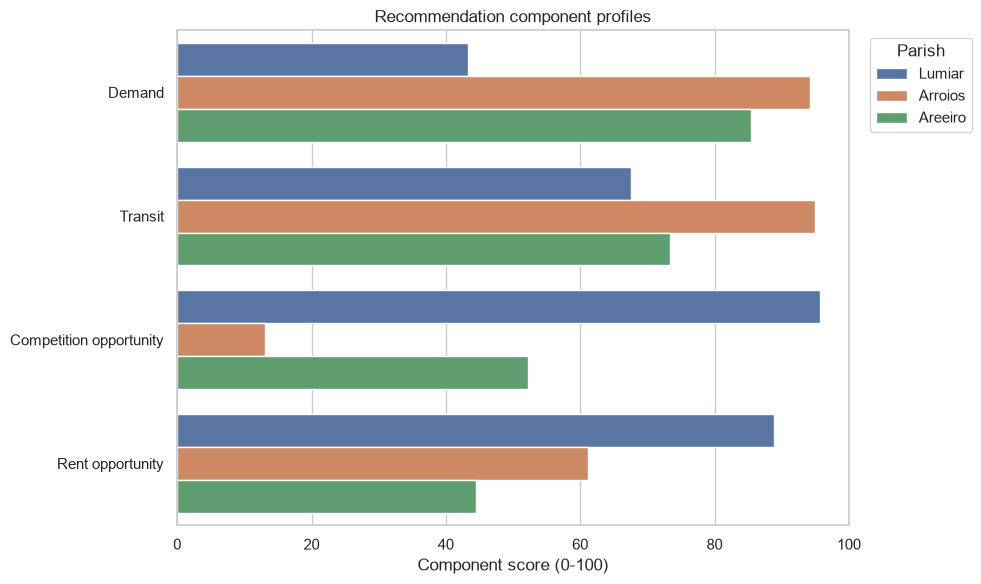

In [5]:
profile_columns = {
    "demand_proxy_score": "Demand",
    "transit_access_score": "Transit",
    "competition_opportunity_score": "Competition opportunity",
    "rent_opportunity_score": "Rent opportunity",
}
profile = final_shortlist[
    ["parish", *profile_columns]
].rename(columns=profile_columns).melt(
    id_vars="parish",
    var_name="component",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=profile,
    x="score",
    y="component",
    hue="parish",
    ax=ax,
)
ax.set_title("Recommendation component profiles")
ax.set_xlabel("Component score (0-100)")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend(title="Parish", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
figure_path = FIGURES_DIR / "09_recommendation_component_profiles.png"
save_figure(fig, figure_path)
plt.show()

## 6. Export recommendation tables

In [6]:
final_shortlist_path = TABLES_DIR / "final_shortlist.csv"
sensitivity_path = (
    TABLES_DIR / "rent_inclusive_shortlist_sensitivity.csv"
)
evidence_path = TABLES_DIR / "recommendation_evidence.csv"

final_shortlist.to_csv(final_shortlist_path, index=False)
sensitivity.to_csv(sensitivity_path, index=False)
evidence.to_csv(evidence_path, index=False)

print("Saved:", final_shortlist_path.relative_to(PROJECT_ROOT))
print("Saved:", sensitivity_path.relative_to(PROJECT_ROOT))
print("Saved:", evidence_path.relative_to(PROJECT_ROOT))

Saved: reports/tables/final_shortlist.csv
Saved: reports/tables/rent_inclusive_shortlist_sensitivity.csv
Saved: reports/tables/recommendation_evidence.csv


## 7. Recommendation boundary

Advance Areeiro, Arroios and Lumiar as a close three-area
shortlist for focused local due diligence. Before any lease decision,
validate live availability, effective occupancy cost, usable
floorplate, footfall and catchment demand, competitor capacity,
planning constraints and unit economics. The parish score
prioritises where to investigate; it does not select a building
or forecast profitability.